# Identifying Mental Health States and Disorders from Online Based Text Data Using Multi-Class Machine Learning Models #

## Introduction ##

The dataset used in this study is publicly available and can be accessed here: https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health?resource=download!

**Dataset License:**
The dataset is released under an Open Database Content license with full usability as stated on Kaggle.

The dataset consists of 53,043 rows of pre-labelled textual data derived from various platforms such as Twitter, Reddit, and other online discussion forums allowing for greater generalisability.

### Study Objectives ###

This study will compare the performance of different machine learning algorithms against multi-class classification metrics such as accuracy, precision, recall, and F1 score. The aim is to evaluate the importance of dataset size, online data source (Reddit, twitter, etc.) and the distinction between mental health states and mental health disorders (such as anxiety vs stress). 

**Algorithms used:**

1. Logistic Regression 
2. Random Forest
3. Decision Tree
4. Complement Naive Bayes

**Mental health categories**
1. Normal
2. Depression
3. Suicidal
4. Anxiety
5. Stress
6. Bipolar
7. Personality Disorder

**Workflow:**

1. Install & load packages
2. Data cleaning & preprocessing
3. Define features and target variable
4. Train–test split
5. TF-IDF vectorization (fit on train only)
6. Handle class imbalance using SMOTE (train only)
7. Train multiple machine learning models
8. Evaluate model performance using metrics & confusion matrices
9. Evaluation: Scores across each model
10. Discussion


**Preventing Data Leakage:**
To avoid data leakage and ensure realistic model performance, the following steps have been taken:

1. Text cleaning and domain-specific normalization were applied only to the raw input statements
2. The dataset was split into train and test sets before any vectorization, preventing the TF-IDF vocabulary from learning patterns from the test data
3. TF-IDF was fitted only on the training set, then applied to the test set using transform() only
4. SMOTE oversampling was applied only to the vectorized training data and never to the test set
5. All machine learning models were trained only on SMOTE-augmented training data to ensure no information leakage

## 1. Install & load packages ##

In [24]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import string
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.svm import LinearSVC
from nltk.corpus import wordnet
import nltk

In [ ]:
#Setting global random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Data cleaning & preprocessing ##

The dataset is explored in detail and is checked for any missing values or duplicates and preprocessed for the next stage.  

In [2]:
# Load dataset
print("Loading data...")
df = pd.read_csv("mental_health_dataset_sarkar.csv")

#Preview dataset 
df.head()

Loading data...


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
#Understanding dataset contents
df.info()
print(df.shape)
print(df.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
(53043, 3)
       Unnamed: 0                                          statement   status
53038       53038  Nobody takes me seriously I’ve (24M) dealt wit...  Anxiety
53039       53039  selfishness  "I don't feel very good, it's lik...  Anxiety
53040       53040  Is there any way to sleep better? I can't slee...  Anxiety
53041       53041  Public speaking tips? Hi, all. I have to give ...  Anxiety
53042       53042  I have really bad door anxiety! It's not about...  Anxiety


In [4]:
#Check any duplicates
df.duplicated(subset=['statement', 'status']).sum()
df[df.duplicated(subset=['statement', 'status'], keep=False)].head()

,Unnamed: 0,statement,status
18,18,"""No regrets or grudges/angry at things that ha...",Anxiety
39,39,but my heart is still restless even though my ...,Anxiety
97,97,"""No regrets or grudges/angry at things that ha...",Anxiety
132,132,I want to exhale the restlessness in my chest ...,Anxiety
138,138,but my heart is still restless even though my ...,Anxiety


In [5]:
#Checking for missing values
print(df.isnull().sum())

Unnamed: 0      0
statement     362
status          0
dtype: int64


### **Results: The dataset contains:** ###
- 53043 instances
- 3 columns(Instance number, Textual data and the label)
- There are **1944 duplicate values** and **362 Missing statements** which will be removed in the next step

In [6]:
#Drop missing values and check if removed 
df = df[['statement', 'status']].dropna()
print(df.isnull().sum())

#Dropping duplicate values and checking if removed 
df = df.drop_duplicates(subset=['statement', 'status'])
df.duplicated(subset=['statement', 'status']).sum()

#Checking final number of results
df.info()


statement    0
status       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 51093 entries, 0 to 52840
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  51093 non-null  object
 1   status     51093 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


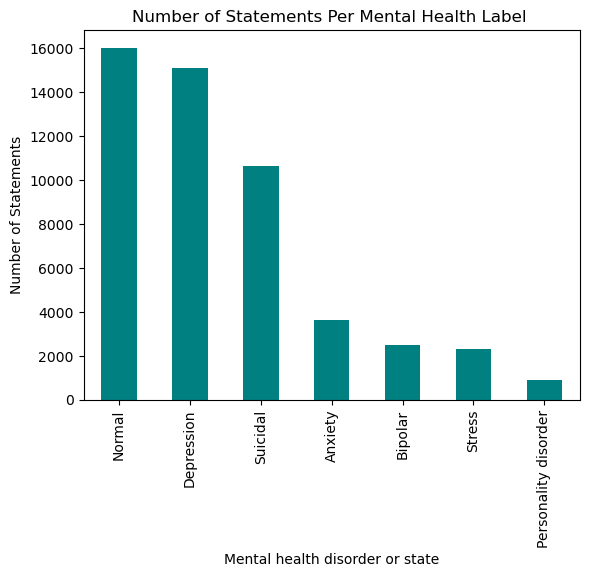

In [7]:
# Bar Chart Visualisation to show how many instances each mental health state contains
df['status'].value_counts().plot(kind='bar', color='teal')
plt.xlabel('Mental health disorder or state')
plt.ylabel('Number of Statements')
plt.title('Number of Statements Per Mental Health Label ')
plt.show()

In [8]:
# Text Cleaning
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


In [9]:
def get_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    return {
        "J": wordnet.ADJ,
        "V": wordnet.VERB,
        "N": wordnet.NOUN,
        "R": wordnet.ADV
    }.get(tag, wordnet.NOUN)


In [10]:
def clean_text(text):
    text = str(text).lower()

    #Expanding Mental health related abbreviations 
    text = re.sub(r"\bkms\b", "kill myself", text)
    text = re.sub(r"\bsh\b","self harm", text)
    text = re.sub(r"\bs/h\b", "self harm", text)
    text = re.sub(r"\bend it\b", "end my life", text)
    text = re.sub(r"\bfreaking out\b", "panic", text)
    
    text = re.sub(r"http\S+|www\S+|@\w+", "", text) # Remove URLs and @handles
    text = re.sub(r"#(\w+)", r"\1", text) #Keep words with hashtags
    text = re.sub(r"[^a-z\s]", "", text) #removing punctuation 
    
    
    #tokenize
    tokens = text.split()

    tokens = [
        lemmatizer.lemmatize(word, get_pos(word))
        for word in tokens
        if word not in stop_words
    ]
    
    return " ".join(tokens)



In [11]:
df['clean_text'] = df['statement'].apply(clean_text)
df[['statement', 'clean_text']].sample(5)

,statement,clean_text
11516,"Goodbye Homelessness, schizophrenia, abusive m...",goodbye homelessness schizophrenia abusive mot...
9529,I make risky decisions and moves just to feel ...,make risky decision move feel something feel l...
40812,theekween it help with depression anxiety and ...,theekween help depression anxiety loss love on...
8393,I am for sure adding clonidine next month afte...,sure add clonidine next month fully get mg lam...
46283,Just about to start work and I feel terrible A...,start work feel terrible month job hunt finall...


URLs, mentions of usernames, and hashtags using regex expressions are removed from the dataset to prevent noise and keep the data anonymous. Even though the dataset in this study is already anonymous, this step also adds an extra layer of support to remove data that could potentially trace the writing back. Non-alphabetic characters except lowercase letters and spaces are removed, and so are stopwords using NLTK's corpus package. 

After printing results, a specific abbreviation 'kms' stood out. This is short for "kill myself" and so the code **text = re.sub(r"\bkms\b", "kill myself", text)** was added in order to preserve this as it is important to the "Suicidal" class and strengthens the meanings within the dataset. Other domain-specific abbreviations and phrases have been expanded as they are key signals in the data that will preserve semantics.

**The dataset is now clean**:
- No missing values
- No duplicates
- Text cleaning ready for processing

Class imbalance will be dealt with in part 6.

## 3. Define features and target variable

In [12]:
# Features and Target
X = df['clean_text']
y = df['status']

## 4. Train–test split

In [13]:
# Train-test split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


## 5. TF-IDF vectorization (fit on train only)

In [14]:
# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1,2), min_df=5, sublinear_tf=True, smooth_idf=True)
X_train_vec = tfidf.fit_transform(X_train_text)
X_test_vec = tfidf.transform(X_test_text)

TF-IDF is used as the main feature extraction due to its ability to identify the meaning behind words within the data.
It applies less weighting to more common words and more weighting to rare meaningful words, so it identifies more discriminative patterns. 
The vectorizer is configured with max_features=15,000, a bi-gram range (1,2), and a minimum document frequency (min_df=5) to balance computational efficiency as well as performance.

## 6. Handle class imbalance using SMOTE (train only)

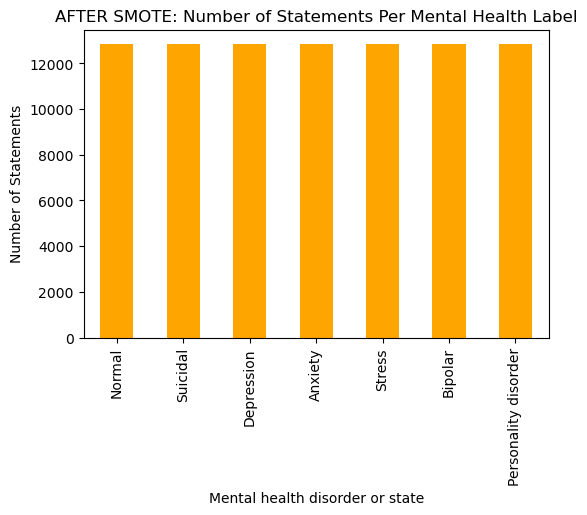

In [15]:
# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_vec_sm, y_train_sm = smote.fit_resample(X_train_vec, y_train)


#visualisation to check SMOTE has been applied correctly
y_train_sm_series = pd.Series(y_train_sm) #converting to series 

#Plotting figure 
plt.figure(figsize=(6,4))
y_train_sm_series.value_counts().plot(kind='bar', color='orange')
plt.xlabel('Mental health disorder or state')
plt.ylabel('Number of Statements')
plt.title('AFTER SMOTE: Number of Statements Per Mental Health Label')
plt.show()

The classes within the dataset are unevenly balanced, with categories such as 'Stress' or 'personality disorder' appearing less frequently in the dataset. Class imbalance has been a challenge in mental health research and studies as some disorders are underrepresented and others more commonly researched. 

SMOTE is applied to the training data only to ensure the test data remains unbiased, and has been selected since it is able to generate synthetic samples for less common minority classes without duplicating the current entries within the data.

While TF-IDF was the main feature extraction method, Bag of Words is used in this study (implemented in later steps) for the Complement Naive Bayes classifier. Bag of Words has shown strong performance in binary and multi-class classification tasks involving Naive Bayes so was selected to maximise the output of this model. Even though SMOTE is applied to handle class imbalance during the training phase, selecting a feature extraction method which enhances each specific algorithm may lead to better performance and results.

## 7. Train multiple machine learning models

In [16]:
# Models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=200,
        class_weight='balanced',
        solver='saga',
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,            
        max_depth=None,              
        min_samples_split=5,    
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1                 
    ),
    

    "Decision Tree": DecisionTreeClassifier(
        max_depth=None,           
        min_samples_split=7,   
        min_samples_leaf=4,       
        class_weight='balanced',
        random_state=42
    ),
    
     "Complement Naive Bayes": ComplementNB(alpha=0.5)

}


- **Logistic Regression** has been shown to be an efficient and well-performing classification technique and has shown high performance in both binary and multi-class classification.
-  **Random Forest** and **Decision Trees** are used in this study for comparative benchmarking, and to assess whether factors such as larger dataset size, multiple mental health classes, and multi- platform data sources, (rather than single-platform data) affect their performance. While previous studies demonstrate lower performance for Decision Trees in suicidal ideation detection, this study will aim to explore whether this may change under the different contexts of this research.
- **Complement Naive Bayes** was used in this study due to its demonstrated strengths in multi-class text classification, especially when used on imbalanced and sparse data.

## 8. Evaluate model performance using metrics & confusion matrices


Training Logistic Regression...

--- Logistic Regression ---
Accuracy: 0.746
                      precision    recall  f1-score   support

             Anxiety       0.73      0.83      0.78       725
             Bipolar       0.78      0.76      0.77       500
          Depression       0.75      0.67      0.71      3019
              Normal       0.91      0.85      0.88      3208
Personality disorder       0.54      0.62      0.58       179
              Stress       0.43      0.63      0.51       459
            Suicidal       0.64      0.70      0.67      2129

            accuracy                           0.75     10219
           macro avg       0.68      0.72      0.70     10219
        weighted avg       0.76      0.75      0.75     10219



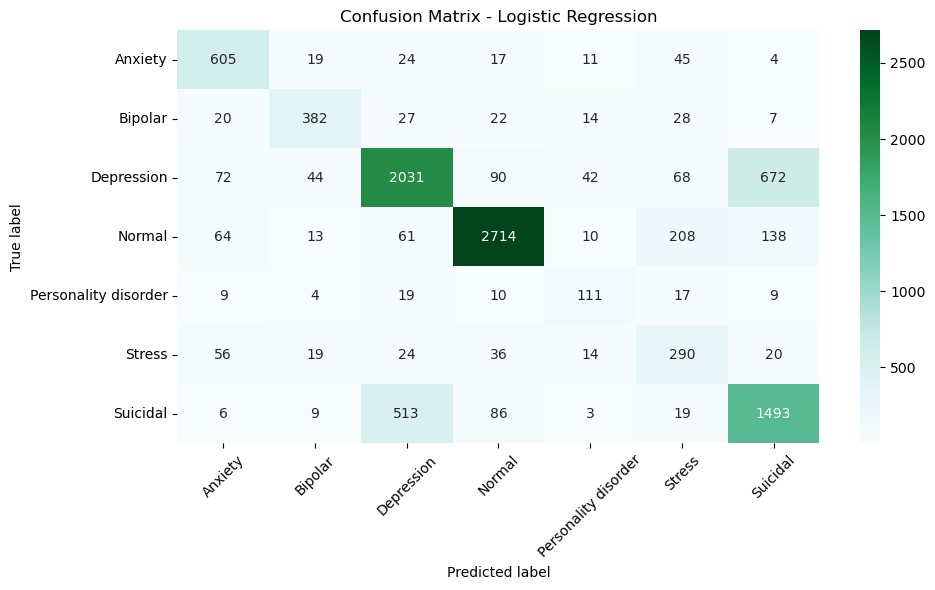


Training Random Forest...

--- Random Forest ---
Accuracy: 0.744
                      precision    recall  f1-score   support

             Anxiety       0.80      0.78      0.79       725
             Bipolar       0.81      0.69      0.74       500
          Depression       0.68      0.70      0.69      3019
              Normal       0.87      0.93      0.90      3208
Personality disorder       0.70      0.37      0.49       179
              Stress       0.49      0.47      0.48       459
            Suicidal       0.65      0.62      0.63      2129

            accuracy                           0.74     10219
           macro avg       0.71      0.65      0.67     10219
        weighted avg       0.74      0.74      0.74     10219



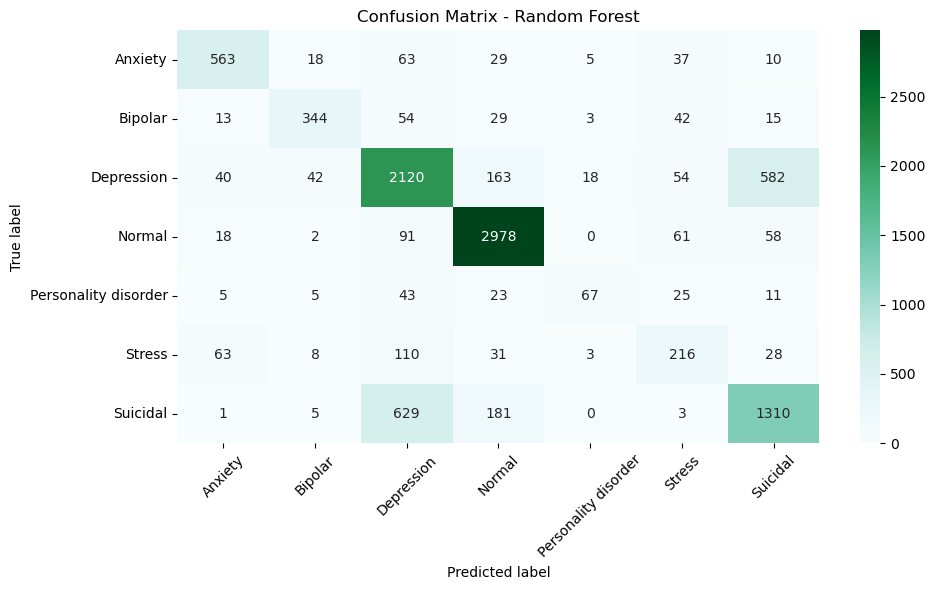


Training Decision Tree...

--- Decision Tree ---
Accuracy: 0.649
                      precision    recall  f1-score   support

             Anxiety       0.58      0.62      0.59       725
             Bipolar       0.64      0.60      0.62       500
          Depression       0.61      0.58      0.60      3019
              Normal       0.85      0.86      0.86      3208
Personality disorder       0.45      0.42      0.44       179
              Stress       0.34      0.44      0.38       459
            Suicidal       0.53      0.50      0.51      2129

            accuracy                           0.65     10219
           macro avg       0.57      0.58      0.57     10219
        weighted avg       0.65      0.65      0.65     10219



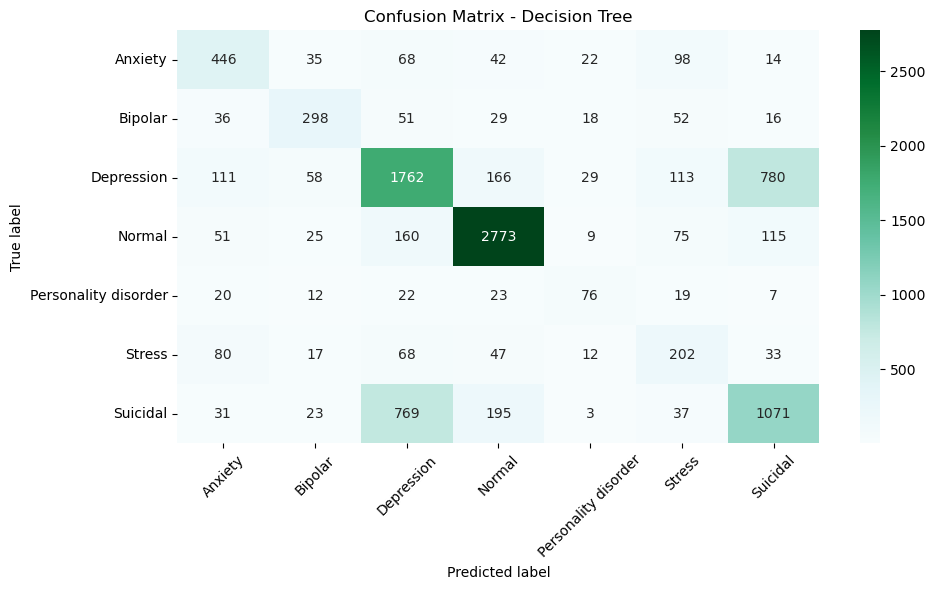


Training Complement Naive Bayes...

--- Complement Naive Bayes ---
Accuracy: 0.604
                      precision    recall  f1-score   support

             Anxiety       0.39      0.90      0.54       725
             Bipolar       0.43      0.81      0.56       500
          Depression       0.64      0.60      0.62      3019
              Normal       0.89      0.48      0.63      3208
Personality disorder       0.61      0.43      0.50       179
              Stress       0.54      0.23      0.32       459
            Suicidal       0.57      0.74      0.64      2129

            accuracy                           0.60     10219
           macro avg       0.58      0.60      0.55     10219
        weighted avg       0.67      0.60      0.60     10219



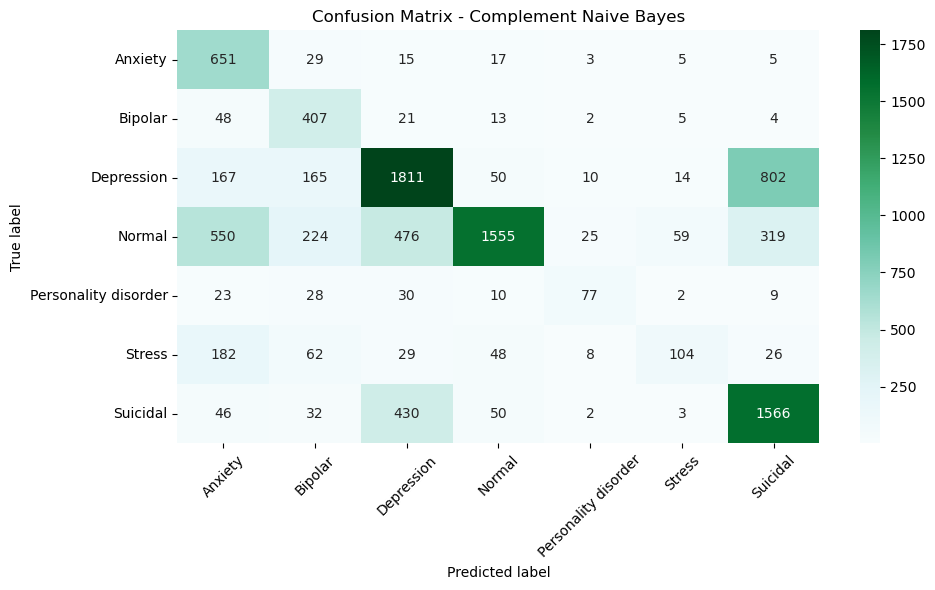

In [17]:
# Train and Evaluate the Models
results = {}
reports = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Special case: Complement NB uses Bag-of-Words instead of TF-IDF
    if name == "Complement Naive Bayes":
        bow = CountVectorizer(max_features=15000, ngram_range=(1,2), min_df=3)
        X_bow_train = bow.fit_transform(X_train_text)
        X_bow_test = bow.transform(X_test_text)

        model.fit(X_bow_train, y_train)
        preds = model.predict(X_bow_test)

    # All other models use TF-IDF + SMOTE
    else:
        model.fit(X_train_vec_sm, y_train_sm)
        preds = model.predict(X_test_vec)

    # Compute accuracy
    acc = accuracy_score(y_test, preds)
    print(f"\n--- {name} ---")
    print("Accuracy:", round(acc, 3))
    print(classification_report(y_test, preds))

    # Save classification report
    report = classification_report(y_test, preds, output_dict=True)
    reports[name] = pd.DataFrame(report).T
    
    # Confusion Matrix
    classes = np.unique(y_test)
    
    cm = confusion_matrix(y_test, preds, labels=classes)

    plt.figure(figsize=(10, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn', 
                xticklabels=classes, yticklabels=classes)

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    results[name] = acc


## 9. Evaluation: Scores across each model ##

In [22]:
#Results table:

summary_rows = []

for model in reports:
    summary_rows.append({
        "Model": model,
        "Accuracy": results[model],
        "Macro F1": reports[model].loc["macro avg", "f1-score"],
        "Weighted F1": reports[model].loc["weighted avg", "f1-score"]
    })

results_table = pd.DataFrame(summary_rows).sort_values(
    by="Macro F1", ascending=False
)

results_table.style.format({
    "Accuracy": "{:.3f}",
    "Macro F1": "{:.3f}",
    "Weighted F1": "{:.3f}"
})

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.746,0.699,0.751
1,Random Forest,0.744,0.675,0.740
2,Decision Tree,0.649,0.571,0.649
3,Complement Naive Bayes,0.604,0.546,0.604


## 10. Discussion ##

### Evaluation Metrics ##

Due to the multi-class and imbalanced nature of the dataset, accuracy alone is not sufficient to evaluate model performance, so the Macro F1 score is prioritised as it treats all classes equally and provides a clearer indication of performance on minority mental health categories. A weighted F1 score is also considered as it reflects the overall performance while accounting for class frequency.


**Best Performing Model:**
- **Logistic Regression** was the best performing model with the highest accuracy of **0.746** and the highest macro score of **0.699**, suggesting the best balance across all the classes. It also has the highest weighted F1 of **0.751** suggesting strong performance on frequent classes. Overall, this model had the most reliable and generalisable performance for multi-class classification for this task. 

---

**Worst Performing Model:** 
- **Complement Naive Bayes** had the weakest performance overall with a lowest Accuracy of **0.604** and the lowest macro F1 of **0.546**. While it was used as a baseline for comparison and it did capture some minority signals well such as Anxiety and Bipolar, its predictions were imbalanced and had poor consistency overall.

---

**Best Performing Categories:**
- **Suicidal**
- **Normal**
- **Depression**
- **Anxiety**

---

**Worst Performing categories:**
- **Stress**
- **Personality Disorder**

These classes suffer from smaller sample sizes and higher linguistic overlap with other mental states, which make them harder to distinguish.
  
---

**Misclassifications:**
- **Depression vs Suicidal:** A consistent source of confusion across all models. This was expected since suicidal ideation can often be a symptom of depression, leading to overlapping language patterns. The lower the model performance, the higher the misclassification rates across the board. 
- **Normal vs Depression/Anxiety/Suicidal:** The normal text often gets misclassified as mental health conditions or states. This could be due to misunderstanding sarcastic language, humour, or ambiguous language which results in the model interpreting this as distress signals. 
- **Anxiety vs Stress:** Surprising result as there is not a lot of misclassification within these results despite their similar nature and language patterns.  

**Conclusion:** The best performing model was **Logistic Regression** with a close second being **Random Forest**. The models overall performed well in identifying mental health categories and distinguishing them from 'normal' language. Depression and Suicidal had the highest misclassifcations suggesting that distinguishing between mental health states and disorders is more complicated due to their overlap. 

**Limitations:**
- It is unclear who labelled the data, whether it was a professional or not which could impact overal generlaisability of the models
- Several mental health categories share overlapping language patterns which can increases misclassification risk if applied to real world settings 
- Contextual nuances such as sarcasm, humour, or even cultural language differences can be a challenge for the models to interpret correctly

**Ethical Considerations:**
- This project is intended for research and educational purposes only and must not be used as a diagnostic or clinical decision making tool
- Mental health predictions generated by machine learning models carry ethical risks, including false positives and false negatives
- Any real-world deployment would require clinical validation, human oversight, and compliance to to data protection and ethical guidelines